In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df = pd.read_csv("sl_household_electricity_appliance_based_1000.csv")

In [4]:
df.head()

,house_size_sqft,people_in_house,bulb_count,ceiling_fan_count,table_fan_count,fridge_count,ac_count,electric_kettle_count,washing_machine_count,tv_count,computer_count,rice_cooker_count,ac_hours_per_day,units,bill_lkr
0,424,5,4,0,1,1,2,2,0,1,2,1,8.56,450,19700.0
1,1492,8,7,2,1,1,1,2,1,2,1,2,5.28,429,18608.0
2,1349,7,8,3,1,1,0,0,1,2,2,1,0.00,259,9768.0
3,486,1,4,1,2,1,1,1,1,0,1,2,8.10,450,19700.0
4,1855,1,9,4,2,1,2,2,1,1,0,0,10.00,450,19700.0


In [5]:
feature_cols = [
    "house_size_sqft",
    "people_in_house",
    "bulb_count",
    "ceiling_fan_count",
    "table_fan_count",
    "fridge_count",
    "ac_count",
    "ac_hours_per_day",
    "electric_kettle_count",
    "washing_machine_count",
    "tv_count",
    "computer_count",
    "rice_cooker_count"
]

X = df[feature_cols]
y = df["bill_lkr"]


In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state =42)

In [9]:
model = RandomForestRegressor(
    n_estimators = 300,
    max_depth = 15,
    random_state =42
)
model.fit(X_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "MLP": MLPRegressor(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # fixed here
    results[name] = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
results_df.sort_values("R2", ascending=False)


C:\Users\navodya sandeepani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,MAE,RMSE,R2
GradientBoosting,1032.669320,1368.221060,0.944081
RandomForest,997.003422,1451.500374,0.937067
Ridge,1673.127204,2067.207393,0.872352
LinearRegression,1673.061207,2067.708955,0.872290
MLP,1813.806071,2180.591742,0.857965
DecisionTree,1522.563333,2333.872464,0.837295
KNN,4208.017333,4996.059930,0.254408


In [12]:
import joblib

# Suppose Random Forest is best
best_model = models["RandomForest"]

joblib.dump(best_model, "best_electricity_model.pkl")
print("Best model saved!")


Best model saved!


In [13]:
new_house = pd.DataFrame({
    "house_size_sqft": [1200],
    "people_in_house": [4],
    "bulb_count": [8],
    "ceiling_fan_count": [2],
    "table_fan_count": [1],
    "fridge_count": [1],
    "ac_count": [1],
    "ac_hours_per_day": [5],
    "electric_kettle_count": [1],
    "washing_machine_count": [1],
    "tv_count": [1],
    "computer_count": [1],
    "rice_cooker_count": [1]
})

predicted_bill = best_model.predict(new_house)[0]
print(f"Predicted Monthly Bill: {predicted_bill:.2f} LKR")


Predicted Monthly Bill: 16758.36 LKR


In [14]:
loaded_model = joblib.load("best_electricity_model.pkl")


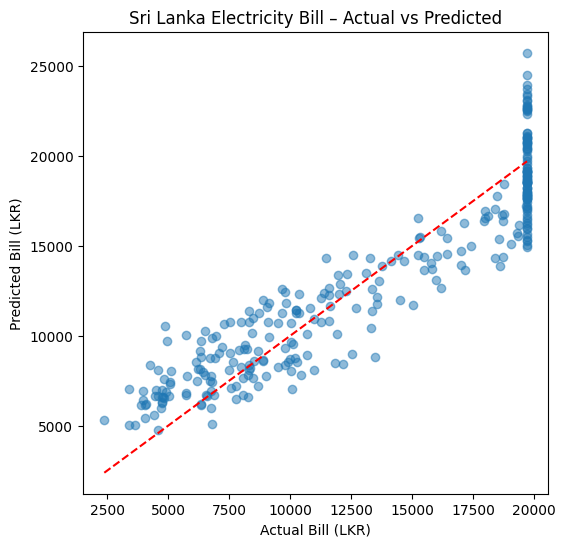

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--", color="red")
plt.xlabel("Actual Bill (LKR)")
plt.ylabel("Predicted Bill (LKR)")
plt.title("Sri Lanka Electricity Bill – Actual vs Predicted")
plt.show()
